# Build ML model for analysis and prediction of DNA-encoded library data.

In [36]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, rdPartialCharges
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

import itertools
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import pathlib
from pathlib import Path
from rdkit import RDLogger
from tqdm.notebook import tqdm

# Get the main logger
logger = RDLogger.logger()

# Set its level to ERROR so only serious messages show up
logger.setLevel(RDLogger.ERROR)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#verify Cuda is actually working

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (runtime):", torch.version.cuda)

print("Torch CUDA libraries loaded:")
for lib in torch.cuda._CudaBase.__module__.split(":"):
    print(lib)

Torch version: 2.8.0+cu128
CUDA available: True
CUDA version (runtime): 12.8
Torch CUDA libraries loaded:
torch.cuda


## Setup.

In [37]:
readout = 'kindel_del'

In [38]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{readout}"
DATA.mkdir(parents=True, exist_ok=True)

In [39]:
import s3fs

for dataset in ['ddr1', 'mapk14']: 
    fs = s3fs.S3FileSystem(anon=True)
    info = fs.info(f'kin-del-2024/data/{dataset}.parquet')
    print(f"File size for {dataset}: {info['size']/1e6:.2f} MB")

File size for ddr1: 6782.18 MB
File size for mapk14: 6911.55 MB


In [40]:
import pyarrow.parquet as pq

def read_first_n_rows(file_path, n_rows):
    parquet_file = pq.ParquetFile(file_path)
    
    num_row_groups = parquet_file.num_row_groups
    
    rows_read = 0
    result = []

    for i in range(num_row_groups):
        row_group = parquet_file.read_row_group(i)
        df = row_group.to_pandas()

        if rows_read + len(df) >= n_rows:
            result.append(df.head(n_rows - rows_read))
            break
        
        result.append(df)
        rows_read += len(df)

    final_df = pd.concat(result, ignore_index=True).head(n_rows)
    return final_df

In [41]:
def count_rows(file_path):
    parquet_file = pq.ParquetFile(file_path)
    total_rows = sum(parquet_file.metadata.row_group(i).num_rows
                     for i in range(parquet_file.num_row_groups))
    return total_rows

In [ ]:
target = f"{DATA}/ddr1.parquet"

row_count = count_rows(target)
print(f"Total rows: {row_count}")

N = 100000  # Number of rows to load - for prototyping
df = read_first_n_rows(target, N)

Total rows: 67641617


### Distribution of sequence counts

In [81]:
# Basic statistics for sequence counts
seq_cols = ['seq_target_1', 'seq_target_2', 'seq_target_3', 'seq_matrix_1', 'seq_matrix_2', 'seq_matrix_3', 'seq_load']
seq_stats = df[seq_cols].describe()

# Check for missing data
missing_data = df[seq_cols].isnull().sum()

# Show a quick overview of the first few rows
seq_stats, missing_data

(       seq_target_1  seq_target_2  seq_target_3  seq_matrix_1  seq_matrix_2  \
 count     1000000.0     1000000.0     1000000.0     1000000.0     1000000.0   
 mean       0.457418      0.541368      0.630889      0.550622      0.620895   
 std        0.872573        0.9906      0.919912      1.766502      1.971061   
 min             0.0           0.0           0.0           0.0           0.0   
 25%             0.0           0.0           0.0           0.0           0.0   
 50%             0.0           0.0           0.0           0.0           0.0   
 75%             1.0           1.0           1.0           1.0           1.0   
 max            17.0          20.0          17.0          81.0          87.0   
 
        seq_matrix_3   seq_load  
 count     1000000.0  1000000.0  
 mean       0.554527  12.019083  
 std        1.691708   10.85121  
 min             0.0        0.0  
 25%             0.0        4.0  
 50%             0.0        9.0  
 75%             1.0       17.0  
 max  

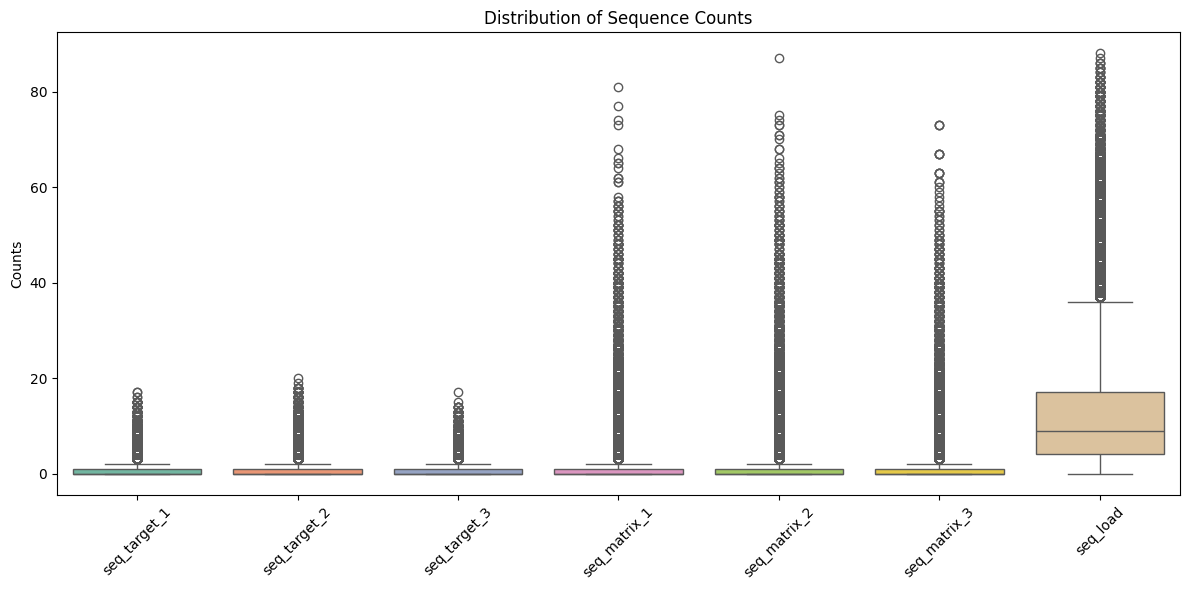

In [82]:
# Plot distribution of sequence counts
plt.figure(figsize=(12, 6))

# Boxplot of sequence counts for target vs control
sns.boxplot(data=df[seq_cols].dropna(), palette="Set2")
plt.title('Distribution of Sequence Counts')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

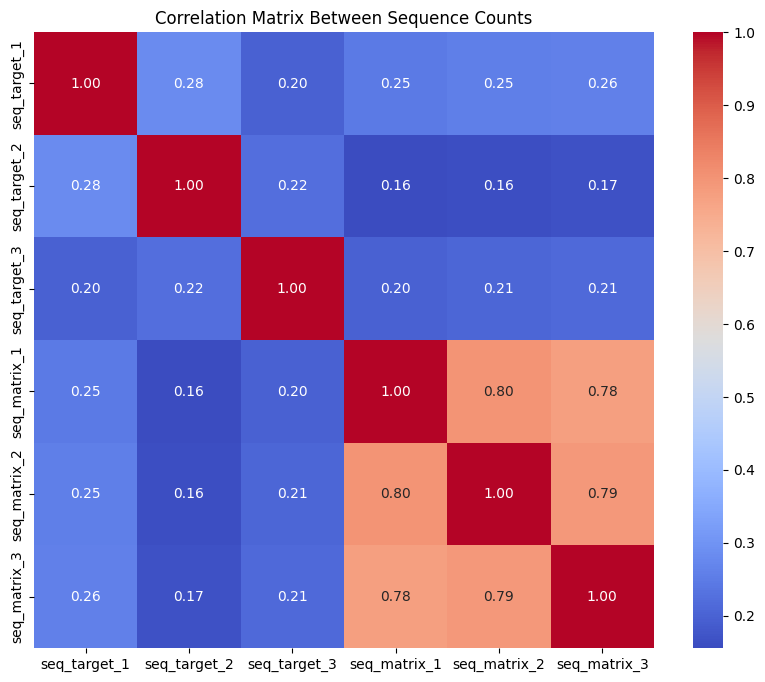

In [83]:
# Correlation between target and control binding
corr_matrix = df[['seq_target_1', 'seq_target_2', 'seq_target_3', 'seq_matrix_1', 'seq_matrix_2', 'seq_matrix_3']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Between Sequence Counts')
plt.show()


/tmp/ipykernel_19049/651964381.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


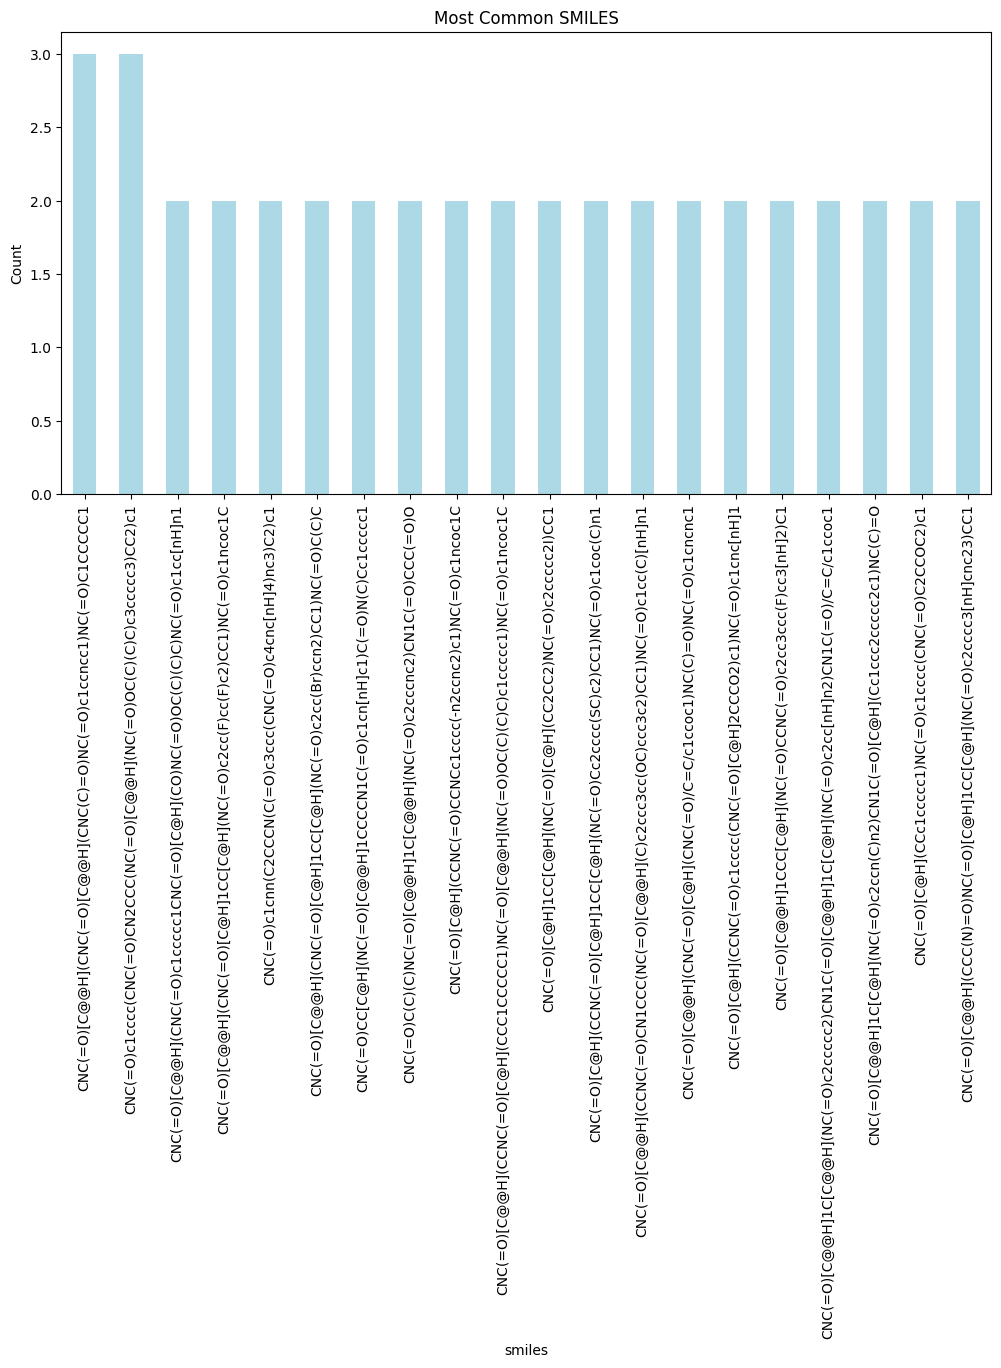

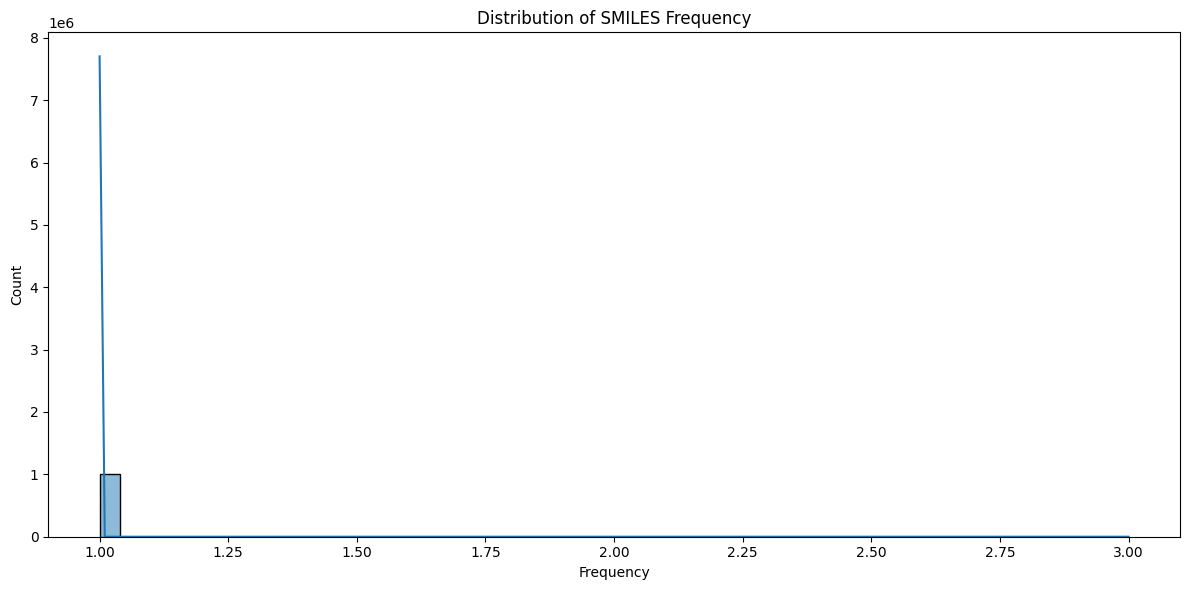

In [84]:
# Distribution of SMILES
smiles_counts = df['smiles'].value_counts()

# Plot the most common SMILES
plt.figure(figsize=(12, 6))
smiles_counts.head(20).plot(kind='bar', color='lightblue')
plt.title('Most Common SMILES')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot distribution of molecule frequency
plt.figure(figsize=(12, 6))
sns.histplot(smiles_counts.values, bins=50, kde=True)
plt.title('Distribution of SMILES Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Synthon analysis.

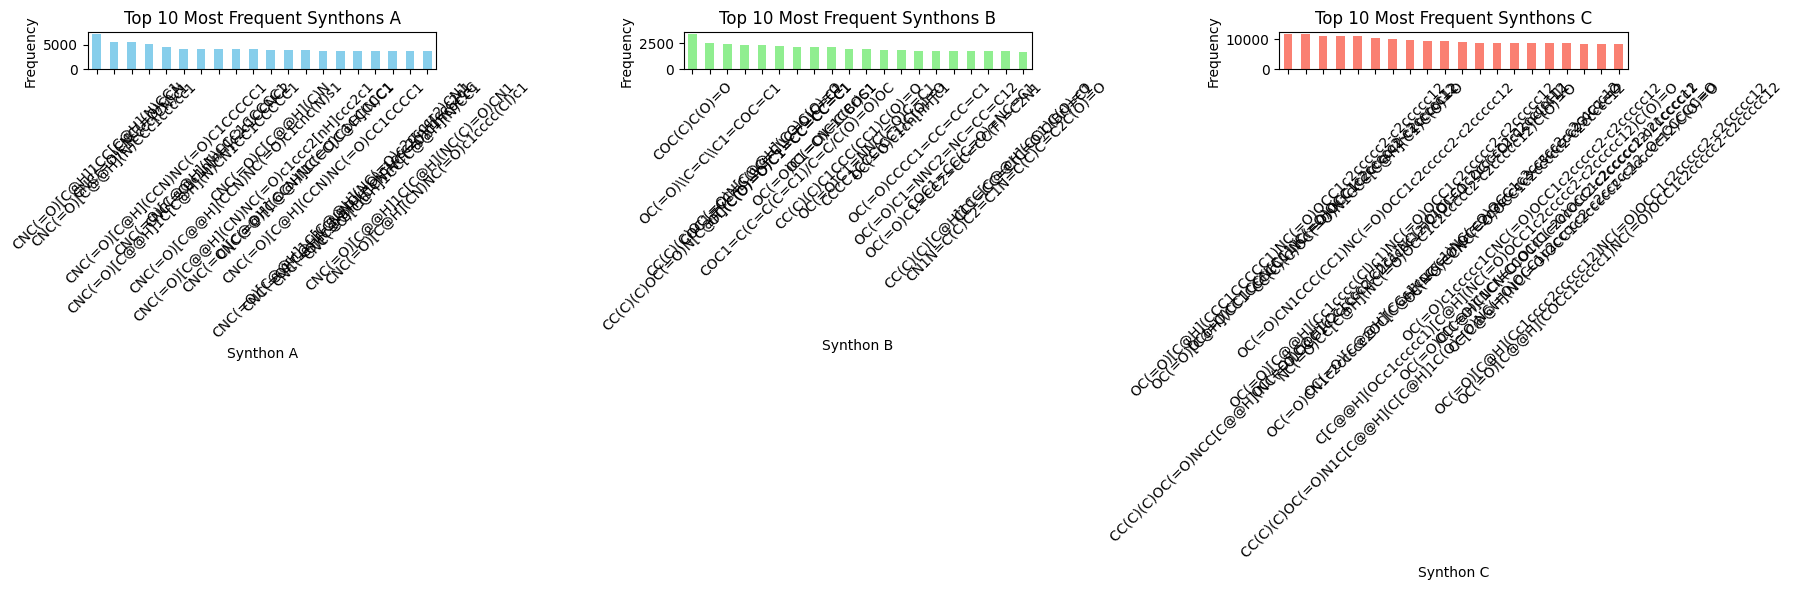

(smiles_a
 CNC(=O)[C@H]1CC[C@H](N)CC1                  7197
 CNC(=O)[C@@H](N)CCc1ccccc1                  5649
 CNC(=O)c1cccc(CN)c1                         5620
 CNC(=O)CCN                                  5085
 CNC(=O)[C@H](CCN)NC(=O)C1CCCCC1             4577
 CNC(=O)[C@@H]1C[C@H](N)CN1CC1CCCCC1         4157
 CNC(=O)[C@@H](N)CCC1CCCCC1                  4106
 CNC(=O)c1n[nH]c2c1CCNC2                     4078
 CNC(=O)[C@@H](CCN)NC(=O)c1cnc(N)s1          4074
 CNC(=O)[C@@H](CN)NC(=O)c1ccc2[nH]ccc2c1     4066
 CNC(=O)C[C@@H](C)N                          4012
 CNC(=O)[C@@H](CCN)NC(=O)C1CCCCC1            3892
 CNC(=O)[C@@H]1CCC[C@H](N)C1                 3859
 CNC(=O)[C@H](CCN)NC(=O)CC1CCCC1             3849
 CNC(=O)[C@@H]1C[C@@H](NC(=O)c2ccccc2)CN1    3842
 CNC(=O)[C@H](CN)NC(=O)c1ccc2[nH]ccc2c1      3771
 CNC(=O)[C@@H](CCN)NC(=O)c1ncoc1C            3707
 CNC(=O)[C@H]1CC[C@@H](N)CC1                 3699
 CNC(=O)[C@@H]1C[C@H](NC(C)=O)CN1            3674
 CNC(=O)[C@H](CN)NC(=O)c1cccc(Cl)c1     

In [85]:
# Frequency analysis of individual synthons (A, B, C)
synthon_cols = ['smiles_a', 'smiles_b', 'smiles_c']

# Count unique occurrences of each synthon in A, B, and C
synthon_a_counts = df['smiles_a'].value_counts()
synthon_b_counts = df['smiles_b'].value_counts()
synthon_c_counts = df['smiles_c'].value_counts()

# Show the top 10 most common synthons
top_10_a = synthon_a_counts.head(20)
top_10_b = synthon_b_counts.head(20)
top_10_c = synthon_c_counts.head(20)

# Plotting the top 10 most frequent synthons for A, B, and C
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot for A
top_10_a.plot(kind='bar', color='skyblue', ax=axs[0])
axs[0].set_title('Top 10 Most Frequent Synthons A')
axs[0].set_ylabel('Frequency')
axs[0].set_xlabel('Synthon A')
axs[0].tick_params(axis='x', rotation=45)

# Plot for B
top_10_b.plot(kind='bar', color='lightgreen', ax=axs[1])
axs[1].set_title('Top 10 Most Frequent Synthons B')
axs[1].set_ylabel('Frequency')
axs[1].set_xlabel('Synthon B')
axs[1].tick_params(axis='x', rotation=45)

# Plot for C
top_10_c.plot(kind='bar', color='salmon', ax=axs[2])
axs[2].set_title('Top 10 Most Frequent Synthons C')
axs[2].set_ylabel('Frequency')
axs[2].set_xlabel('Synthon C')
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display the top counts
top_10_a, top_10_b, top_10_c


Top 10 Most Frequent Synthon A (Structures)


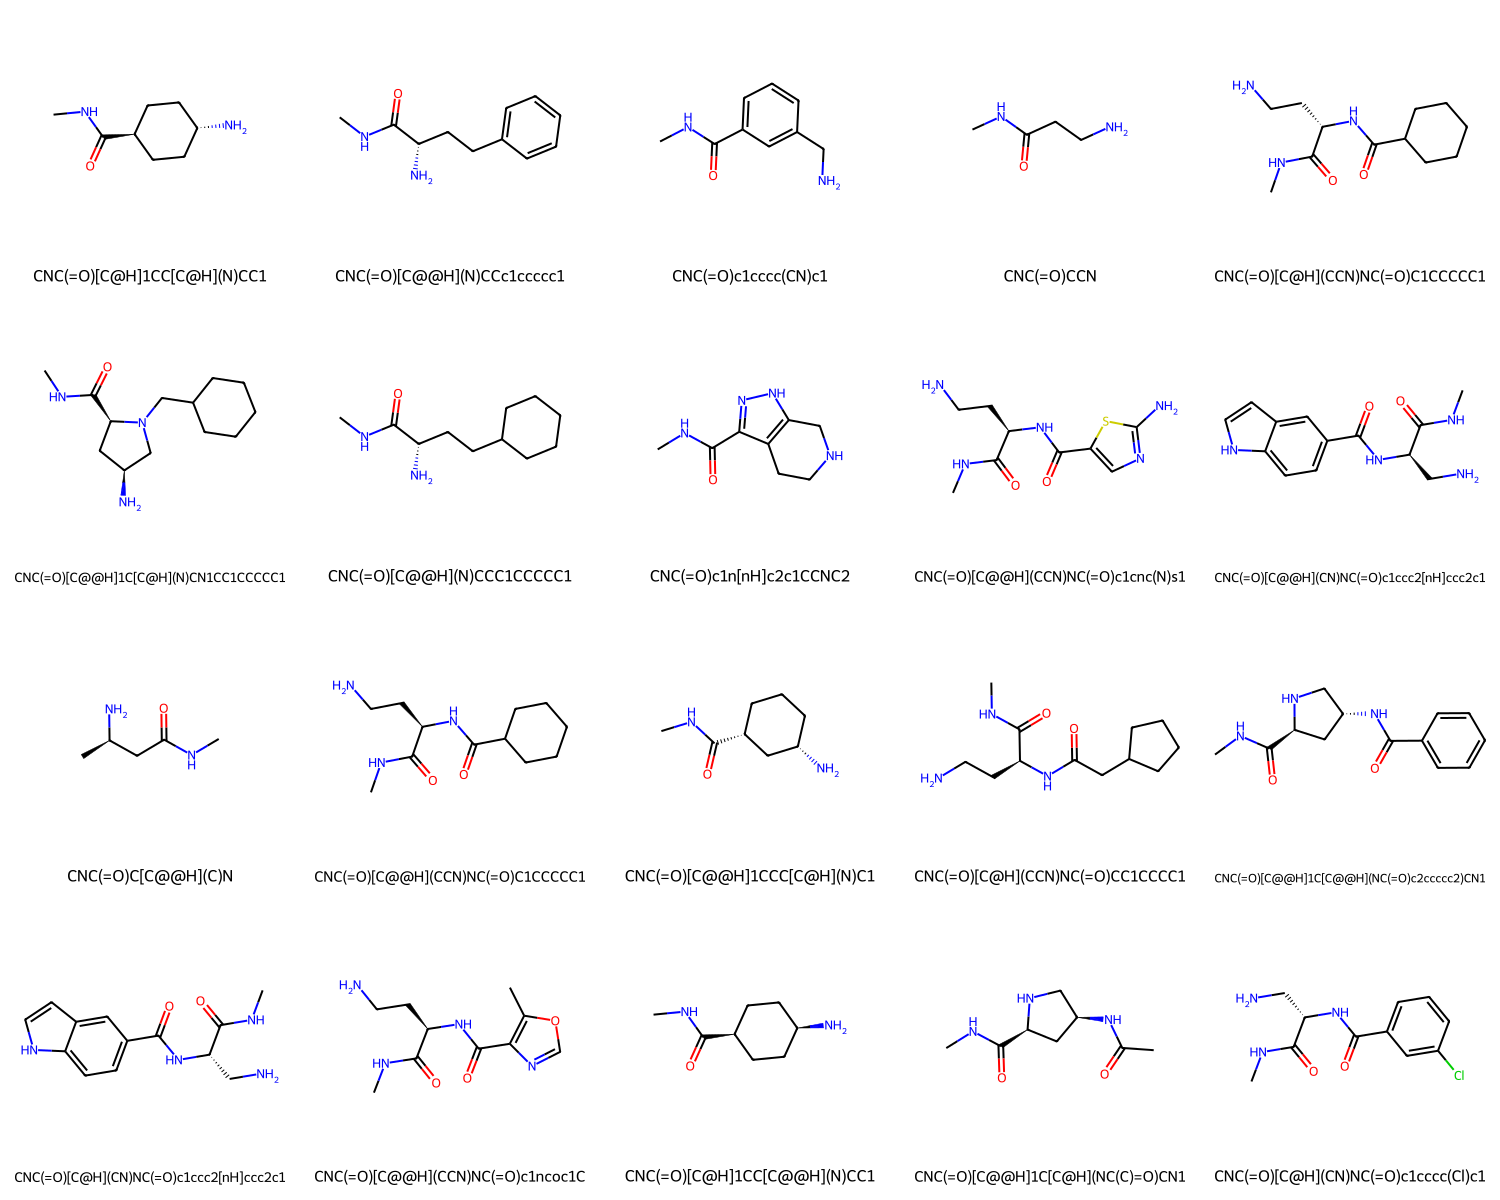

Top 10 Most Frequent Synthon B (Structures)


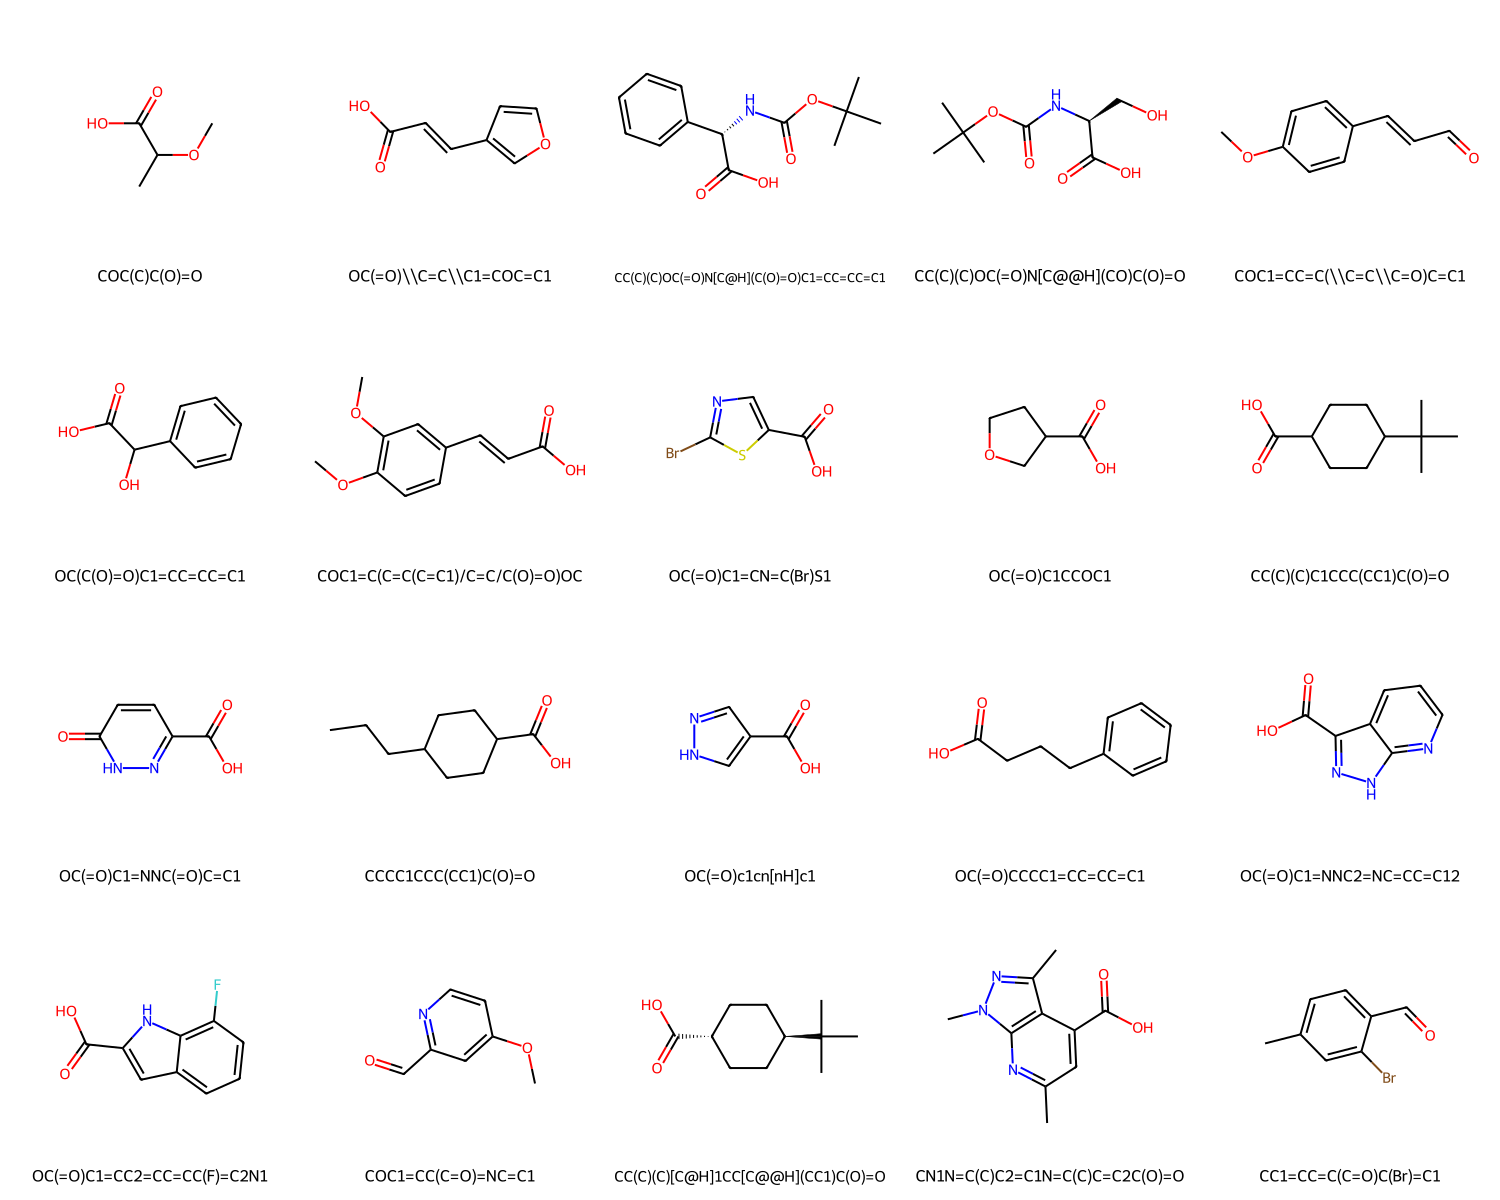

Top 10 Most Frequent Synthon C (Structures)


[16:11:49] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,
[16:11:49] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,' for input: 'CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,'
[16:11:49] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,
[16:11:49] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,' for input: 'CC(C)(C)OC(=O)N1C[C@@H](C[C@H]1C(O)=O)NC(=O)OCC1c2ccccc2-c2ccccc12,'


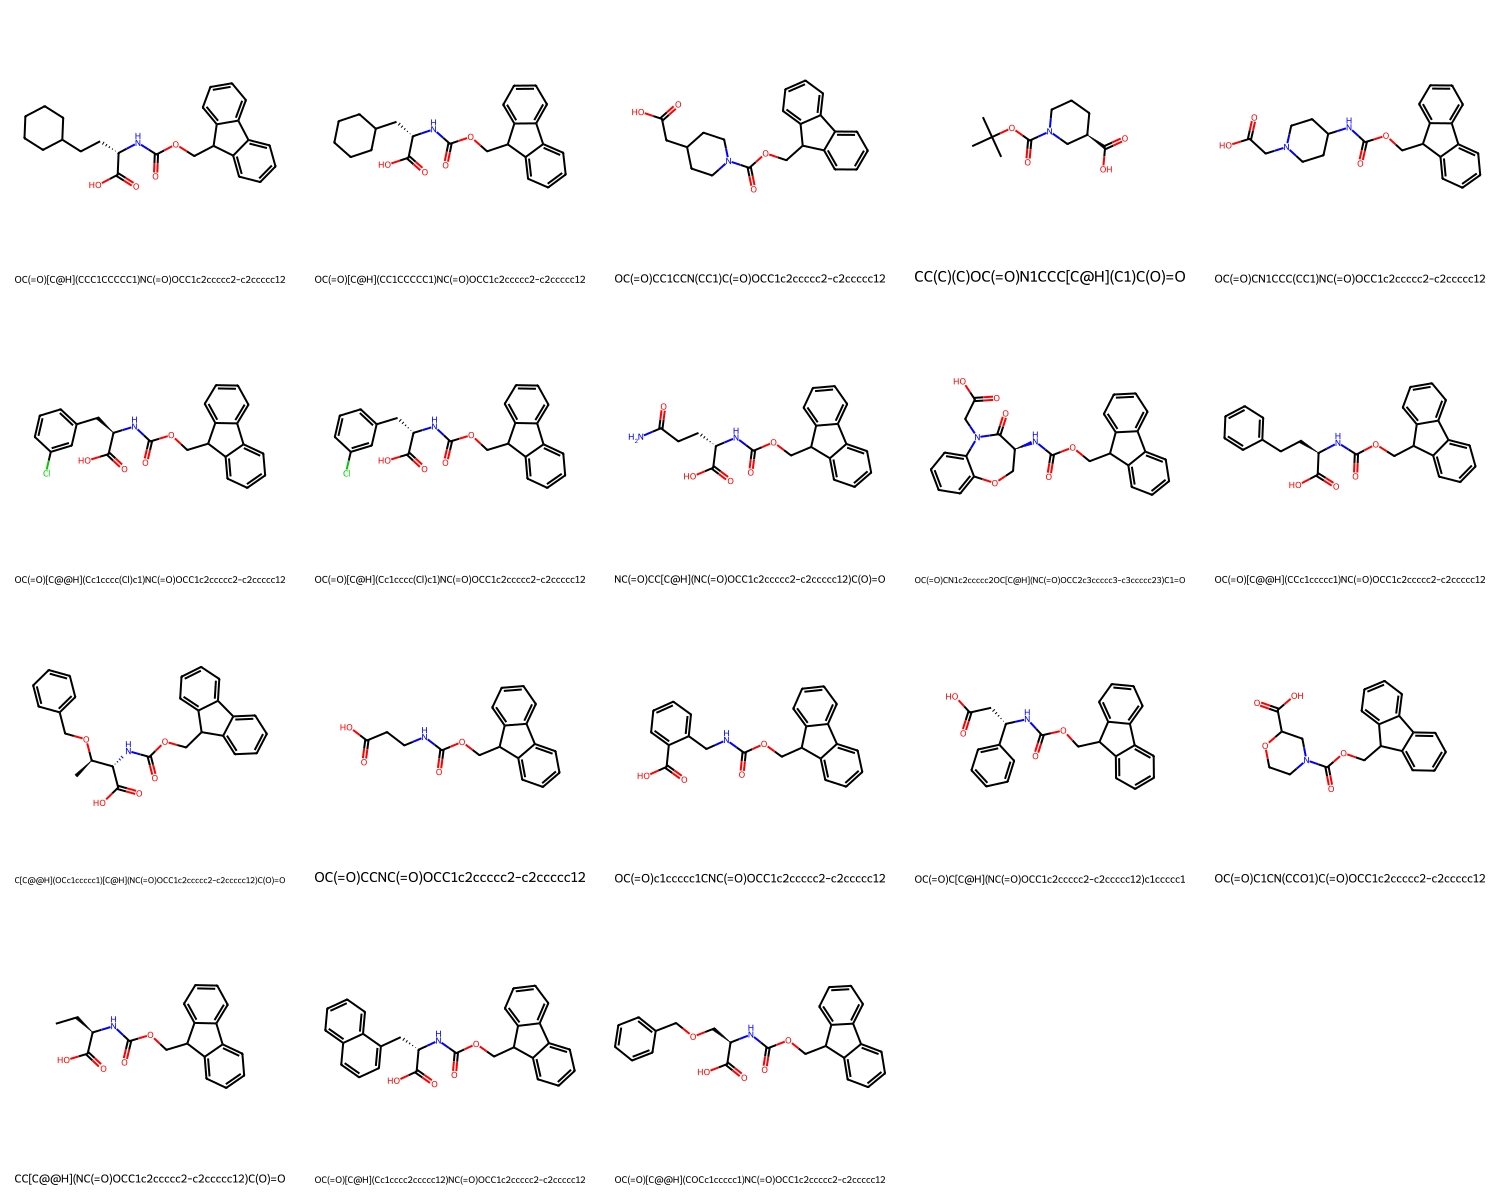

In [86]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def plot_smiles(smiles_list, title="Molecular Structures", max_display=20):
    smiles_list = list(smiles_list)[:max_display]
    molecules = [Chem.MolFromSmiles(sm) for sm in smiles_list]
    
    # Filter out invalid molecules
    valid_pairs = [(mol, sm) for mol, sm in zip(molecules, smiles_list) if mol is not None]
    if not valid_pairs:
        print(f"No valid molecules found for {title}")
        return
    molecules, smiles_list = zip(*valid_pairs)
    
    # Generate grid image
    img = Draw.MolsToGridImage(
        list(molecules),
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=list(smiles_list),
        useSVG=False  # Returns PIL.Image.Image
    )
    
    print(title)
    display(img)  # Display inline in Jupyter

# Plot the top synthons
plot_smiles(top_10_a.index.tolist(), title="Top 10 Most Frequent Synthon A (Structures)")
plot_smiles(top_10_b.index.tolist(), title="Top 10 Most Frequent Synthon B (Structures)")
plot_smiles(top_10_c.index.tolist(), title="Top 10 Most Frequent Synthon C (Structures)")


Top 10 Synthon Pairs (A-B) Structures


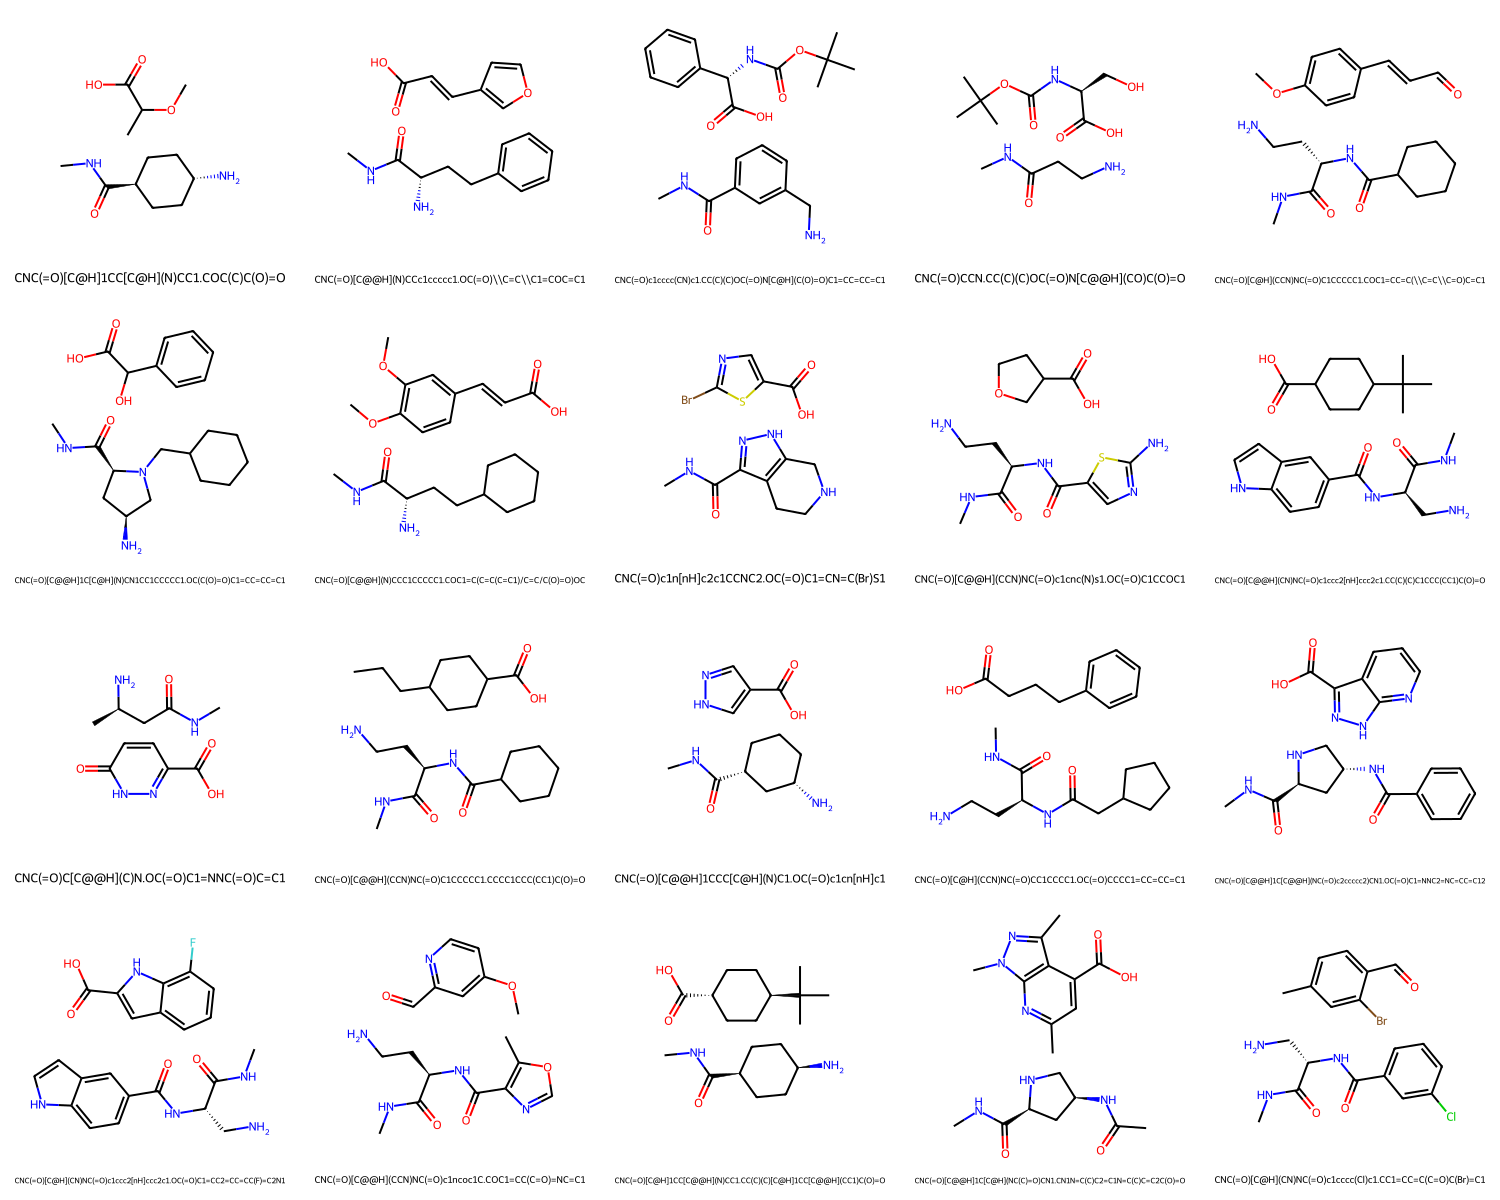

In [87]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def plot_synthon_pairs(pair_list, title="Synthon Pair Structures", max_display=20):
    # Only take the first max_display pairs
    pair_list = pair_list[:max_display]
    
    # Combine pairs as disconnected molecules using "."
    pair_smiles = [f"{a}.{b}" for a, b in pair_list]
    
    # Convert SMILES to RDKit molecules, filter invalid ones
    valid_pairs = [(Chem.MolFromSmiles(sm), sm) for sm in pair_smiles if Chem.MolFromSmiles(sm) is not None]
    if not valid_pairs:
        print(f"No valid molecules found for {title}")
        return
    molecules, legends = zip(*valid_pairs)
    
    # Generate grid image
    img = Draw.MolsToGridImage(
        list(molecules),
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=list(legends),
        useSVG=False  # Returns PIL.Image.Image
    )
    
    print(title)
    display(img)  # Display inline in Jupyter

# Create top 10 pairs of synthons A-B
pair_ab_list = list(zip(top_10_a.index, top_10_b.index))

# Plot the pairs
plot_synthon_pairs(pair_ab_list, title="Top 10 Synthon Pairs (A-B) Structures")


Top 10 Synthon Triplet Pairs (A-B, A-C, B-C) Structures (A-B Pairs)


[16:11:51] SMILES Parse Error: syntax error while parsing: CNC(=O)CCN.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,
[16:11:51] SMILES Parse Error: Failed parsing SMILES 'CNC(=O)CCN.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,' for input: 'CNC(=O)CCN.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,'
[16:11:51] SMILES Parse Error: syntax error while parsing: CC(C)(C)OC(=O)N[C@@H](CO)C(O)=O.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,
[16:11:51] SMILES Parse Error: Failed parsing SMILES 'CC(C)(C)OC(=O)N[C@@H](CO)C(O)=O.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,' for input: 'CC(C)(C)OC(=O)N[C@@H](CO)C(O)=O.CC(C)(C)OC(=O)NCC[C@@H](NC(=O)OCC1c2ccccc2-c2ccccc12)C(O)=O,'


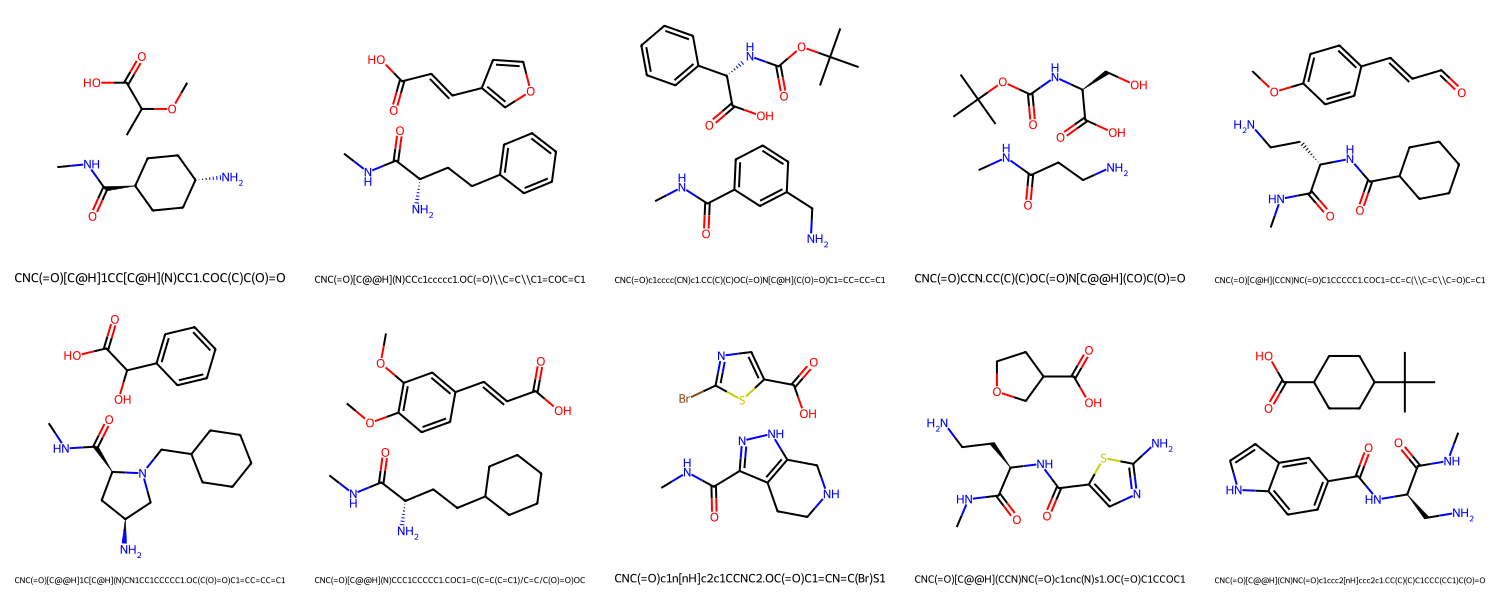

Top 10 Synthon Triplet Pairs (A-B, A-C, B-C) Structures (A-C Pairs)


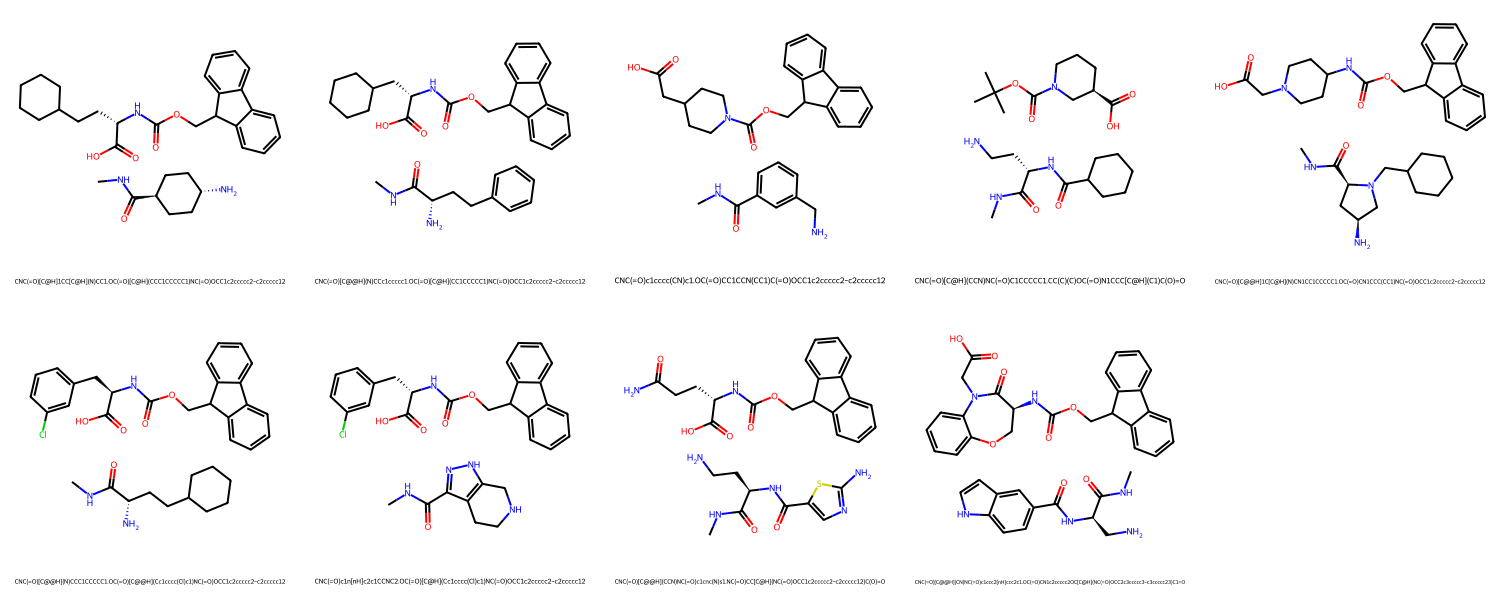

Top 10 Synthon Triplet Pairs (A-B, A-C, B-C) Structures (B-C Pairs)


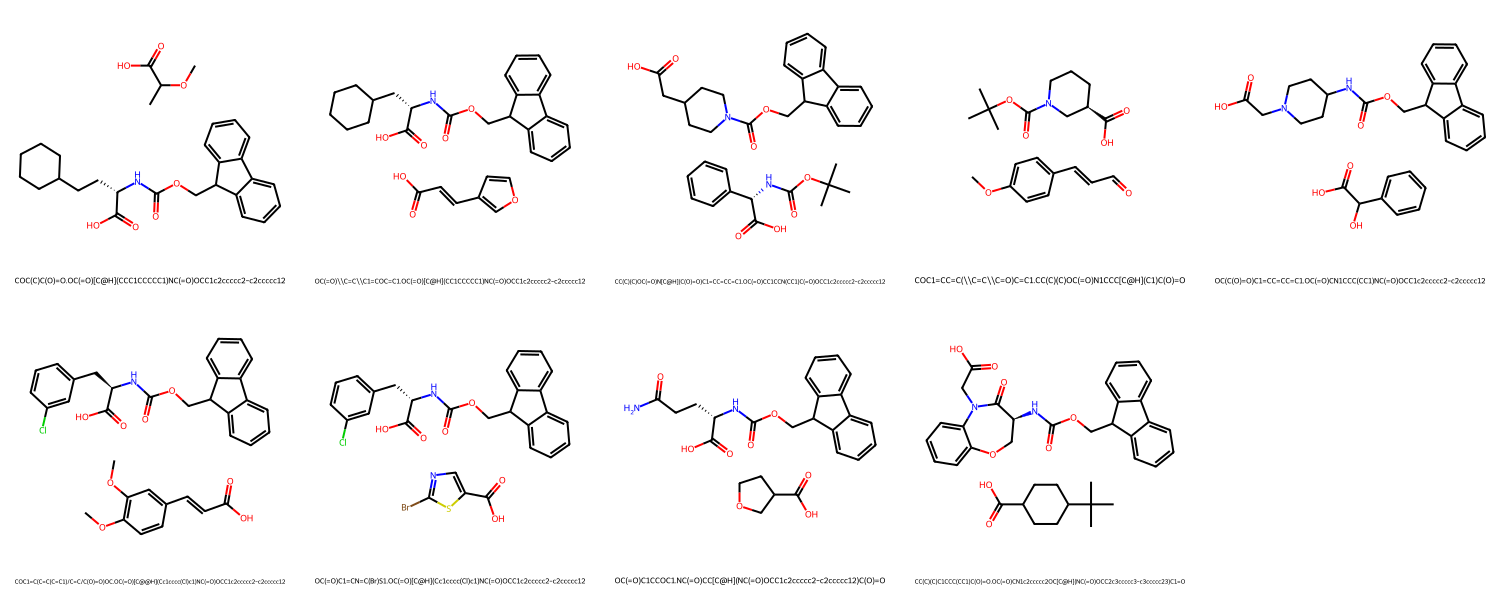

In [88]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

def plot_synthon_triplets(pair_list_ab, pair_list_ac, pair_list_bc, title="Synthon Triplet Structures", max_display=10):
    """
    Visualizes synthon triplets (A-B, A-C, B-C) as molecular structures.
    """
    # Only take the first max_display pairs from each list
    pair_list_ab = pair_list_ab[:max_display]
    pair_list_ac = pair_list_ac[:max_display]
    pair_list_bc = pair_list_bc[:max_display]
    
    # Combine pairs as disconnected molecules using "."
    pair_smiles_ab = [f"{a}.{b}" for a, b in pair_list_ab]
    pair_smiles_ac = [f"{a}.{c}" for a, c in pair_list_ac]
    pair_smiles_bc = [f"{b}.{c}" for b, c in pair_list_bc]
    
    # Convert SMILES to RDKit molecules, filter invalid ones
    valid_ab = [(Chem.MolFromSmiles(sm), sm) for sm in pair_smiles_ab if Chem.MolFromSmiles(sm) is not None]
    valid_ac = [(Chem.MolFromSmiles(sm), sm) for sm in pair_smiles_ac if Chem.MolFromSmiles(sm) is not None]
    valid_bc = [(Chem.MolFromSmiles(sm), sm) for sm in pair_smiles_bc if Chem.MolFromSmiles(sm) is not None]
    
    if not valid_ab or not valid_ac or not valid_bc:
        print(f"No valid molecules found for {title}")
        return
    
    # Extract molecules and legends for each pair type
    molecules_ab, legends_ab = zip(*valid_ab)
    molecules_ac, legends_ac = zip(*valid_ac)
    molecules_bc, legends_bc = zip(*valid_bc)
    
    # Generate grid images for each pair type
    img_ab = Draw.MolsToGridImage(
        list(molecules_ab),
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=list(legends_ab),
        useSVG=False  # Returns PIL.Image.Image
    )
    
    img_ac = Draw.MolsToGridImage(
        list(molecules_ac),
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=list(legends_ac),
        useSVG=False
    )
    
    img_bc = Draw.MolsToGridImage(
        list(molecules_bc),
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=list(legends_bc),
        useSVG=False
    )
    
    # Display the images inline
    print(f"{title} (A-B Pairs)")
    display(img_ab)
    
    print(f"{title} (A-C Pairs)")
    display(img_ac)
    
    print(f"{title} (B-C Pairs)")
    display(img_bc)

# Create top 10 pairs of synthons A-B, A-C, B-C
pair_ab_list = list(zip(top_10_a.index, top_10_b.index))
pair_ac_list = list(zip(top_10_a.index, top_10_c.index))
pair_bc_list = list(zip(top_10_b.index, top_10_c.index))

# Plot the top 10 synthon triplet pairs
plot_synthon_triplets(pair_ab_list, pair_ac_list, pair_bc_list, title="Top 10 Synthon Triplet Pairs (A-B, A-C, B-C) Structures")


### Correlation with binding affinity

In [95]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Assume the dataset is loaded as a DataFrame
# df = pd.read_parquet('your_data.parquet')

# For this example, let's assume `df` contains the following columns:
# 'smiles_a', 'smiles_b', 'smiles_c', 'seq_target_1', 'seq_target_2', 'seq_target_3'

# Step 1: Extract relevant columns
synthon_pairs = df[['smiles_a', 'smiles_b', 'smiles_c']]
binding_data = df[['seq_target_1', 'seq_target_2', 'seq_target_3']]

# Step 2: Calculate binding affinity (we can use the mean of the 3 sequence counts as a proxy for binding affinity)
df['mean_binding_affinity'] = binding_data.mean(axis=1)

# Step 3: Create synthon pair strings (A.B, A.C, B.C)
df['pair_ab'] = df['smiles_a'] + '.' + df['smiles_b']
df['pair_ac'] = df['smiles_a'] + '.' + df['smiles_c']
df['pair_bc'] = df['smiles_b'] + '.' + df['smiles_c']

# Step 4: Calculate correlation between synthon pairs and binding affinity
def calculate_pair_correlation(pair_column, binding_column):
    # Calculate Spearman correlation between the pair and binding affinity
    correlation, _ = spearmanr(df[pair_column].astype('category').cat.codes, df[binding_column])
    return correlation

# Calculate correlation for each pair
correlation_ab = calculate_pair_correlation('pair_ab', 'mean_binding_affinity')
correlation_ac = calculate_pair_correlation('pair_ac', 'mean_binding_affinity')
correlation_bc = calculate_pair_correlation('pair_bc', 'mean_binding_affinity')

# Print the correlations
print(f"Correlation between pair A-B and binding affinity: {correlation_ab}")
print(f"Correlation between pair A-C and binding affinity: {correlation_ac}")
print(f"Correlation between pair B-C and binding affinity: {correlation_bc}")


Correlation between pair A-B and binding affinity: -0.0029959998191312655
Correlation between pair A-C and binding affinity: -0.0027483960030645666
Correlation between pair B-C and binding affinity: 0.013212106318731062


/tmp/ipykernel_19049/2126218687.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_values, y=pair_labels, palette='coolwarm')


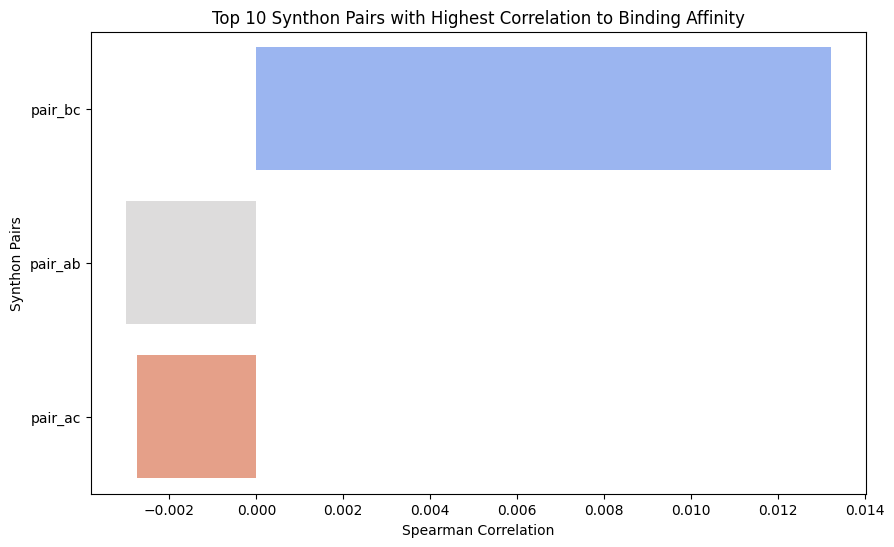

In [96]:
# List of pairs to check
pair_columns = ['pair_ab', 'pair_ac', 'pair_bc']
correlations = {}

# Calculate correlation for each pair
for pair in pair_columns:
    correlations[pair] = calculate_pair_correlation(pair, 'mean_binding_affinity')

# Step 2: Rank the synthon pairs by their correlation value
# Convert the dictionary into a sorted list
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

# Step 3: Visualize the top N synthon pairs with highest correlation
top_n = 10  # Number of top pairs to show
top_pairs = sorted_correlations[:top_n]

# Prepare data for plotting
pair_labels = [pair[0] for pair in top_pairs]
correlation_values = [pair[1] for pair in top_pairs]

# Step 4: Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_values, y=pair_labels, palette='coolwarm')
plt.title(f"Top {top_n} Synthon Pairs with Highest Correlation to Binding Affinity")
plt.xlabel('Spearman Correlation')
plt.ylabel('Synthon Pairs')
plt.show()

In [102]:
df.smiles.head(1).to_list()

['CNC(=O)[C@@H](CNC(=O)[C@H](CCC1CCCCC1)NC(=O)c1ccc2c(c1)OC(F)(F)O2)NC(=O)c1ccncc1']

In [103]:
df.smiles_a.head(1).to_list()

['CNC(=O)[C@@H](CN)NC(=O)c1ccncc1']

In [104]:
df.smiles_b.head(1).to_list()

['OC(=O)C1=CC2=C(OC(F)(F)O2)C=C1']

In [105]:
df.smiles_c.head(1).to_list()

['OC(=O)[C@H](CCC1CCCCC1)NC(=O)OCC1c2ccccc2-c2ccccc12']